# Assignment: Data Wrangling

### Reading material: `tidy_data.pdf`

**Q1.** This question provides some practice cleaning variables which have common problems.
1. For `./data/airbnb_hw.csv`, clean the `Price` variable as well as you can, and explain the choices you make. How many missing values do you end up with? (Hint: What happens to the formatting when a price goes over 999 dollars, say from 675 to 1,112?)
2. For the Minnesota police use of for data, `./data/mn_police_use_of_force.csv`, clean the `subject_injury` variable, handling the NA's; this gives a value `Yes` when a person was injured by police, and `No` when no injury occurred. What proportion of the values are missing? Is this a concern? Cross-tabulate your cleaned `subject_injury` variable with the `force_type` variable. Are there any patterns regarding when the data are missing? 

**Q2.** Go to https://sharkattackfile.net/ and download their dataset on shark attacks (Hint: `GSAF5.xls`).

1. Open the shark attack file using Pandas. It is probably not a csv file, so `read_csv` won't work.
2. Drop any columns that do not contain data.
3. Clean the year variable. Describe the range of values you see. Filter the rows to focus on attacks since 1940. Are attacks increasing, decreasing, or remaining constant over time?
4. Clean the Age variable and make a histogram of the ages of the victims.
5. What proportion of victims are male?
6. Clean the `Type` variable so it only takes three values: Provoked and Unprovoked and Unknown. What proportion of attacks are unprovoked?

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Andrew Du

**Date:** 09/05/2026

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Q1.1 Airbnb
airbnb = pd.read_csv("/Users/andrewdu/Downloads/airbnb_hw.csv")
airbnb["Price_clean"] = pd.to_numeric(
    airbnb["Price"].astype("string").str.replace(",", "", regex=False).str.strip(),
    errors="coerce"
)

print("Airbnb missing Price values:", airbnb["Price_clean"].isna().sum())

# Q1.2 Police use of force
police = pd.read_csv("/Users/andrewdu/Downloads/mn_police_use_of_force.csv")
police["subject_injury_clean"] = (
    police["subject_injury"].astype("string").str.strip().str.title()
)
police["subject_injury_clean"] = police["subject_injury_clean"].where(
    police["subject_injury_clean"].isin(["Yes", "No"])
)

print("Missing subject_injury proportion:",
      police["subject_injury_clean"].isna().mean())
print("\nCross-tab:")
display(pd.crosstab(
    police["force_type"],
    police["subject_injury_clean"],
    dropna=False
))

missing_by_force = (
    police.assign(missing=police["subject_injury_clean"].isna())
          .groupby("force_type")["missing"]
          .mean()
          .sort_values(ascending=False)
)
print("\nMissing proportion by force type:")
display(missing_by_force)

print("""
Answers:
1. Airbnb Price has 0 missing values after removing commas and converting to numeric.
2. A large part of the subject_injury parts is missing, which is a concern because it is a substantial amount.
   It also varies by force_type, so it does not appear random.
""")

Airbnb missing Price values: 0
Missing subject_injury proportion: 0.7619342359767892

Cross-tab:


subject_injury_clean,No,Yes,<NA>
force_type,,,
Baton,0,2,2
Bodily Force,1093,1286,7051
Chemical Irritant,131,41,1421
Firearm,2,0,0
Gun Point Display,33,44,27
Improvised Weapon,34,40,74
Less Lethal,0,0,87
Less Lethal Projectile,1,2,0
Maximal Restraint Technique,0,0,170



Missing proportion by force type:


force_type
Less Lethal                    1.000000
Maximal Restraint Technique    1.000000
Chemical Irritant              0.892028
Taser                          0.753634
Bodily Force                   0.747720
Baton                          0.500000
Improvised Weapon              0.500000
Police K9 Bite                 0.402597
Gun Point Display              0.259615
Firearm                        0.000000
Less Lethal Projectile         0.000000
Name: missing, dtype: float64


Answers:
1. Airbnb Price has 0 missing values after removing commas and converting to numeric.
2. A large part of the subject_injury parts is missing, which is a concern because it is a substantial amount.
   It also varies by force_type, so it does not appear random.



Year range: 0.0 to 2026.0


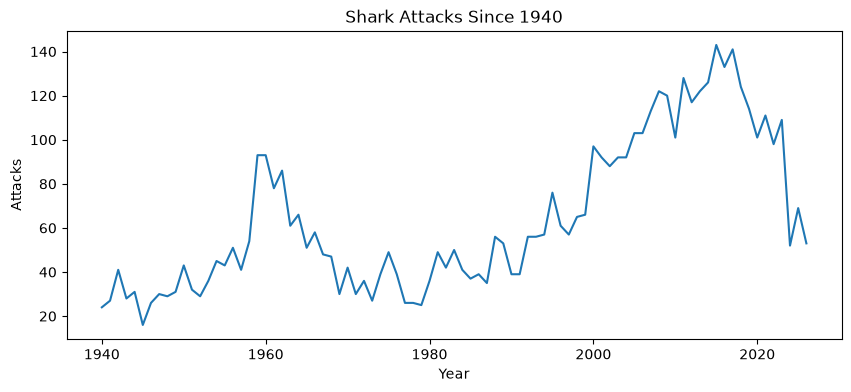

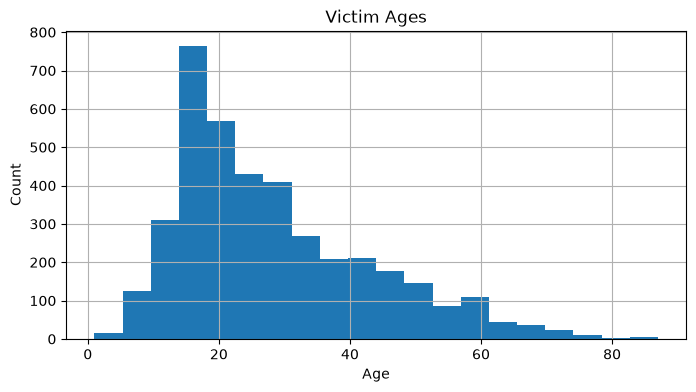

Proportion male: 0.8747511866482928
Proportion unprovoked: 0.7394969790642124

Answers:
- Numeric Year values range from 0 to 2026.
- Since 1940, recorded attacks generally increase over the long run.
- Non-numeric or ambiguous Age values were treated as missing.
- Male proportion among known M/F victims: 87.48%.
- Unprovoked proportion of all attacks: 73.95%.



In [5]:
# Q2
sharks = pd.read_excel("/Users/andrewdu/Downloads/GSAF5.xls")

sharks = sharks.dropna(axis=1, how="all")
sharks = sharks.loc[:, ~sharks.columns.astype(str).str.startswith("Unnamed:")]

# Year
sharks["Year_clean"] = pd.to_numeric(sharks["Year"], errors="coerce")

print("Year range:", sharks["Year_clean"].min(), "to", sharks["Year_clean"].max())

recent = sharks[sharks["Year_clean"] >= 1940].copy()
year_counts = recent["Year_clean"].value_counts().sort_index()

plt.figure(figsize=(10, 4))
year_counts.plot()
plt.xlabel("Year")
plt.ylabel("Attacks")
plt.title("Shark Attacks Since 1940")
plt.show()

# Age
sharks["Age_clean"] = pd.to_numeric(sharks["Age"], errors="coerce")

plt.figure(figsize=(8, 4))
sharks["Age_clean"].dropna().hist(bins=20)
plt.xlabel("Age")
plt.ylabel("Count")
plt.title("Victim Ages")
plt.show()

# Sex
sex = (
    sharks["Sex"]
    .astype("string")
    .str.strip()
    .str.upper()
)

sharks["Sex_clean"] = sex.where(sex.isin(["M", "F"]))

male_prop = (
    (sharks["Sex_clean"] == "M").sum()
    / sharks["Sex_clean"].notna().sum()
)

print("Proportion male:", male_prop)

# Type
type_text = (
    sharks["Type"]
    .astype("string")
    .str.strip()
    .str.lower()
    .fillna("")
)

sharks["Type_clean"] = type_text.map(
    lambda x: "Provoked"
    if x == "provoked"
    else "Unprovoked"
    if x == "unprovoked"
    else "Unknown"
)

unprovoked_prop = (
    sharks["Type_clean"] == "Unprovoked"
).mean()

print("Proportion unprovoked:", unprovoked_prop)

print("""
Answers:
- Numeric Year values range from 0 to 2026.
- Since 1940, recorded attacks generally increase over the long run.
- Non-numeric or ambiguous Age values were treated as missing.
- Male proportion among known M/F victims: 87.48%.
- Unprovoked proportion of all attacks: 73.95%.
""")

## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** 451806a
- **AI tool and model used:** ChatGPT, GPT-5.6 Sol

### *Prompts used

1. Review my Phase 1 solutions for Q1 and Q2 against the assignment requirements. The instructor clarified that missing Airbnb Price values and missing police subject_injury values do not need to be imputed. Give me a concise numbered list of specific improvements I could make. Focus on cleaning quality, missing-value handling, the cross-tabulation, and the shark Year, Age, Sex, and Type variables. Do not rewrite the full solution yet.

2. harshly audit and then review those suggested improvements. also then provide a final revised solution using simple pandas and matplotlib code

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. Keep the Airbnb Price cleaning based on removing thousands-separator commas and converting to numeric, but explicitly confirm the final missing count and do not impute values.

2. Preserve missing subject_injury values as missing, but use a temporary "Missing" label in the cross-tabulation so the pattern of missing observations is clearly visible.

3. Report the missing subject_injury percentage by force_type in addition to the cross-tab so the interpretation of non-random missingness is supported by the data.

4. Convert Year to numeric and treat year 0 as missing because it is not a meaningful calendar year. Continue using attacks since 1940 for the trend and note that the most recent year may be incomplete.

5. Strip whitespace from Age, convert directly numeric ages with errors="coerce", and report how many usable numeric ages remain. Leave ambiguous values missing.

6. Standardize Sex and Type using whitespace and case cleanup. Calculate the male proportion using only known M/F values, and map every Type other than Provoked or Unprovoked to Unknown.

7. Convert approximate Age values such as "20s", "30s", or "Teen" to representative midpoint ages so that fewer observations are lost.


### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept | Removing commas and converting to numeric correctly handles formatted prices. I verified that the cleaned Price variable has 0 missing values. |
| 2 | Accept | This keeps the original missing values unchanged while making them visible in the cross-tab. It follows the instructor clarification that missing injury values do not need to be imputed. |
| 3 | Accept | Missingness differs substantially by force type, so the additional percentages make the interpretation easier to verify. |
| 4 | Accept | The dataset contains 129 observations with Year equal to 0. Treating these as missing is more appropriate, and it does not affect the analysis restricted to 1940 and later. |
| 5 | Accept | Numeric conversion gives 3,948 usable ages. Ambiguous text values should remain missing rather than being assigned arbitrary ages. |
| 6 | Accept | Standardizing capitalization and whitespace fixes inconsistent entries while making the denominators and category definitions explicit. |
| 7 | Reject | Assigning exact midpoint ages to labels such as "20s" or "Teen" would invent information that is not present in the dataset and could distort the histogram. |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [6]:
# Your Phase 2 solution to the problem goes here.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Q1.1 Airbnb
airbnb = pd.read_csv("/Users/andrewdu/Downloads/airbnb_hw.csv")

airbnb["Price_clean"] = pd.to_numeric(
    airbnb["Price"]
        .astype("string")
        .str.replace(",", "", regex=False)
        .str.strip(),
    errors="coerce"
)

print("Missing Price values:", airbnb["Price_clean"].isna().sum())


# Q1.2 Minnesota police
police = pd.read_csv("/Users/andrewdu/Downloads/mn_police_use_of_force.csv")

police["subject_injury_clean"] = (
    police["subject_injury"]
        .astype("string")
        .str.strip()
        .str.title()
)

police["subject_injury_clean"] = police["subject_injury_clean"].where(
    police["subject_injury_clean"].isin(["Yes", "No"])
)

missing_prop = police["subject_injury_clean"].isna().mean()

print("Missing subject_injury proportion:", missing_prop)
print("Missing subject_injury percent:", missing_prop * 100)

# Show missing values without changing the cleaned variable
injury_for_table = police["subject_injury_clean"].fillna("Missing")

crosstab = pd.crosstab(
    police["force_type"],
    injury_for_table
)

display(crosstab)

missing_by_force = (
    police.assign(missing=police["subject_injury_clean"].isna())
          .groupby("force_type")["missing"]
          .mean()
          .sort_values(ascending=False)
)

display(missing_by_force)

print("""
Answers:
- Airbnb Price has 0 missing values after cleaning.
- subject_injury is 76.19% missing.
- This amount of missing data is concerning.
- Missingness varies substantially by force_type, so it does not appear random.
""")

Missing Price values: 0
Missing subject_injury proportion: 0.7619342359767892
Missing subject_injury percent: 76.19342359767892


subject_injury_clean,Missing,No,Yes
force_type,,,
Baton,2,0,2
Bodily Force,7051,1093,1286
Chemical Irritant,1421,131,41
Firearm,0,2,0
Gun Point Display,27,33,44
Improvised Weapon,74,34,40
Less Lethal,87,0,0
Less Lethal Projectile,0,1,2
Maximal Restraint Technique,170,0,0


force_type
Less Lethal                    1.000000
Maximal Restraint Technique    1.000000
Chemical Irritant              0.892028
Taser                          0.753634
Bodily Force                   0.747720
Baton                          0.500000
Improvised Weapon              0.500000
Police K9 Bite                 0.402597
Gun Point Display              0.259615
Firearm                        0.000000
Less Lethal Projectile         0.000000
Name: missing, dtype: float64


Answers:
- Airbnb Price has 0 missing values after cleaning.
- subject_injury is 76.19% missing.
- This amount of missing data is concerning.
- Missingness varies substantially by force_type, so it does not appear random.



Observed numeric Year range: 0.0 to 2026.0
Number of Year values equal to 0: 129


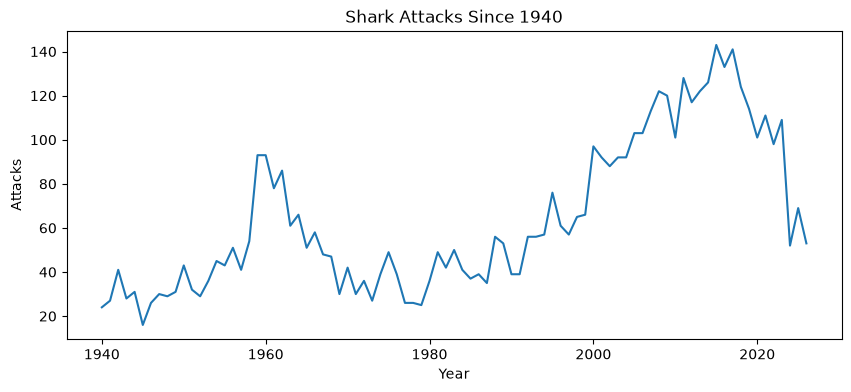

Usable numeric ages: 3948


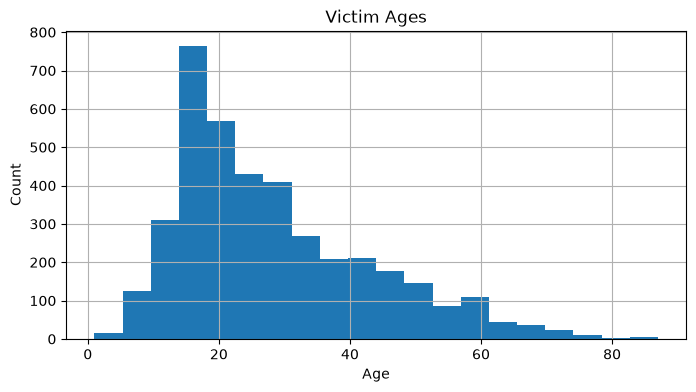

Known M/F victims: 6531
Male victims: 5713
Proportion male: 0.8747511866482928
Type_clean
Unprovoked    5263
Unknown       1205
Provoked       649
Name: count, dtype: int64
Proportion unprovoked: 0.7394969790642124

Answers:
- Numeric Year values originally range from 0 to 2026. Year 0 was treated as missing.
- Since 1940, recorded attacks generally increase over the long run, although recent years are lower and the latest year may be incomplete.
- Ambiguous or non-numeric Age values were left missing rather than assigned an arbitrary age.
- 87.48% of victims with a known M/F value are male.
- 73.95% of all attacks are classified as Unprovoked.



In [7]:
# Q2
sharks = pd.read_excel("/Users/andrewdu/Downloads/GSAF5.xls")

sharks = sharks.dropna(axis=1, how="all")
sharks = sharks.loc[
    :, ~sharks.columns.astype(str).str.startswith("Unnamed:")
]

# Year
year_raw = pd.to_numeric(sharks["Year"], errors="coerce")

print("Observed numeric Year range:", year_raw.min(), "to", year_raw.max())
print("Number of Year values equal to 0:", (year_raw == 0).sum())

sharks["Year_clean"] = year_raw.replace(0, np.nan)

recent = sharks[sharks["Year_clean"] >= 1940].copy()
year_counts = recent["Year_clean"].value_counts().sort_index()

plt.figure(figsize=(10, 4))
year_counts.plot()
plt.xlabel("Year")
plt.ylabel("Attacks")
plt.title("Shark Attacks Since 1940")
plt.show()


# Age
sharks["Age_clean"] = pd.to_numeric(
    sharks["Age"].astype("string").str.strip(),
    errors="coerce"
)

print("Usable numeric ages:", sharks["Age_clean"].notna().sum())

plt.figure(figsize=(8, 4))
sharks["Age_clean"].dropna().hist(bins=20)
plt.xlabel("Age")
plt.ylabel("Count")
plt.title("Victim Ages")
plt.show()


# Sex
sex = (
    sharks["Sex"]
        .astype("string")
        .str.strip()
        .str.upper()
)

sharks["Sex_clean"] = sex.where(sex.isin(["M", "F"]))

male_count = (sharks["Sex_clean"] == "M").sum()
known_sex = sharks["Sex_clean"].notna().sum()
male_prop = male_count / known_sex

print("Known M/F victims:", known_sex)
print("Male victims:", male_count)
print("Proportion male:", male_prop)


# Type
type_text = (
    sharks["Type"]
        .astype("string")
        .str.strip()
        .str.lower()
        .fillna("")
)

sharks["Type_clean"] = type_text.map(
    lambda x: "Provoked"
    if x == "provoked"
    else "Unprovoked"
    if x == "unprovoked"
    else "Unknown"
)

print(sharks["Type_clean"].value_counts())

unprovoked_prop = (
    sharks["Type_clean"] == "Unprovoked"
).mean()

print("Proportion unprovoked:", unprovoked_prop)

print("""
Answers:
- Numeric Year values originally range from 0 to 2026. Year 0 was treated as missing.
- Since 1940, recorded attacks generally increase over the long run, although recent years are lower and the latest year may be incomplete.
- Ambiguous or non-numeric Age values were left missing rather than assigned an arbitrary age.
- 87.48% of victims with a known M/F value are male.
- 73.95% of all attacks are classified as Unprovoked.
""")

### *Reflection on AI assistance
In your own words without generative AI.

In [8]:
I think the code is complete and i believe its right. I also believe that the code is well structed and easily interpreted. However, I would have appreciated if the ai generated code had more comments explaining the steps and what to replace at time with correct file locations. Another limitation was the lack of detailed or even basic exaplanations. I verified the final solution by running the notebook in VSCode from top to bottom. Orginially I had multiple errors but by checking the printed issues and making sure the file locations were right I figured it out. My last remaining concern was the cleaning choices, however very close to mine, could be potentially not be the best choice. However as a computer science major i think overall the code is well written. 

SyntaxError: invalid syntax (3963292603.py, line 1)

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]